# Feature Distributions

In [12]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew
warnings.filterwarnings('ignore')

In [2]:
# pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
# pd.reset_option("display.max_rows")
# pd.reset_option("display.max_columns")

## Import Data

In [4]:
# Exclude shootout shots (period = 5)
df = pd.read_csv('/Users/graham/Projects/xG_model/data/processed/nhl_shots_cleaned_features.csv')
df


,game_id,event_id,sort_order,period,period_type,shooting_team_strength_state,shooting_team_strength_diff,shooter_id,goalie_id,team_id,shooter_team_abbrev,opponent_team_abbrev,is_home_team,event_type,x_coord,y_coord,zone,shot_type,is_goal,miss_reason,time_into_period_sec,empty_net_shot
0,2019020001,10,11,1,REG,5v5,0,8480801,8475883.0,9,OTT,TOR,0,goal,85.0,-1.0,O,tip-in,1,on-net,25,0
1,2019020001,12,15,1,REG,5v5,0,8479458,8475883.0,9,OTT,TOR,0,missed-shot,28.0,-37.0,O,slap,0,wide-of-net,38,0
2,2019020001,15,28,1,REG,5v4,1,8476853,8467950.0,10,TOR,OTT,1,shot-on-goal,32.0,-2.0,O,snap,0,on-net,91,0
3,2019020001,18,33,1,REG,5v4,1,8478483,8467950.0,10,TOR,OTT,1,missed-shot,46.0,-16.0,O,wrist,0,wide-of-net,118,0
4,2019020001,19,44,1,REG,5v5,0,8478857,8467950.0,10,TOR,OTT,1,missed-shot,64.0,-4.0,O,tip-in,0,wide-of-net,189,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618900,2024021312,1074,721,3,REG,5v5,0,8475231,8482982.0,2,NYI,CBJ,0,shot-on-goal,80.0,-4.0,O,backhand,0,on-net,1074,0
618901,2024021312,1078,727,3,REG,5v5,0,8478460,8477405.0,29,CBJ,NYI,1,shot-on-goal,31.0,33.0,O,slap,0,on-net,1107,0
618902,2024021312,1082,732,3,REG,5v5,0,8484166,8477405.0,29,CBJ,NYI,1,goal,62.0,32.0,O,wrist,1,on-net,1117,0
618903,2024021312,1086,736,3,REG,5v5,0,8483485,8477405.0,29,CBJ,NYI,1,shot-on-goal,37.0,31.0,O,slap,0,on-net,1160,0


## Numeric Continuous

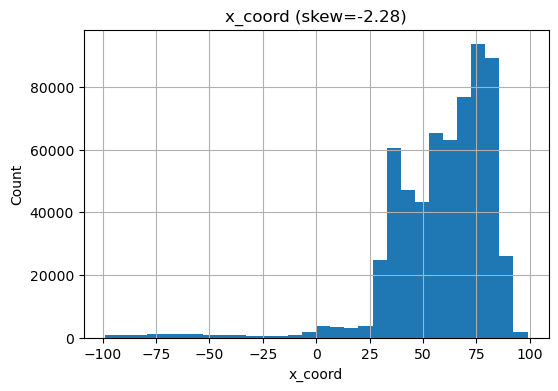

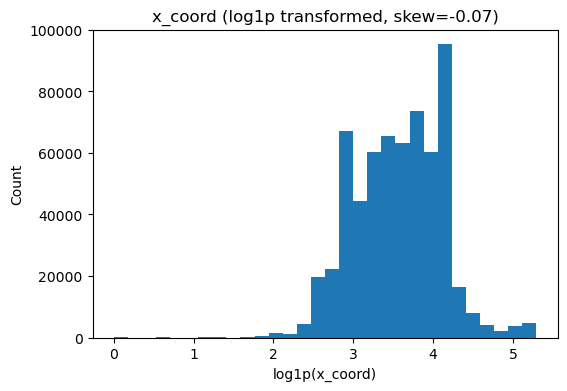

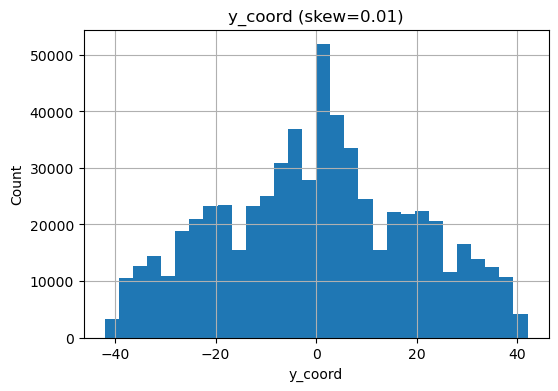

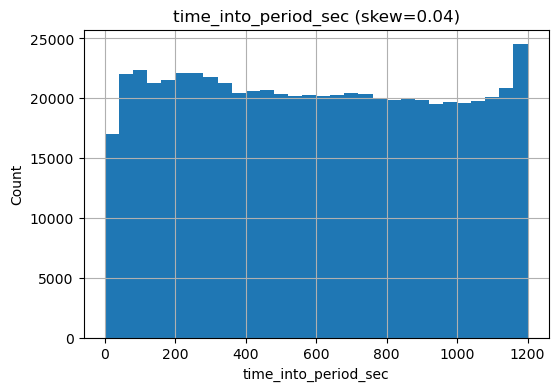

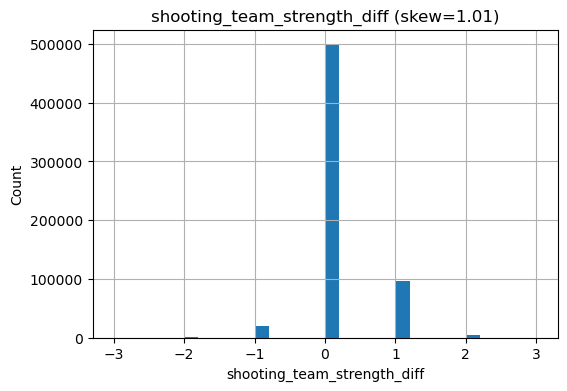

In [27]:
num_continuous = ['x_coord', 'y_coord', 'time_into_period_sec', 'shooting_team_strength_diff']
for col in num_continuous:
    # Compute skewness of original data
    col_skew = skew(df[col].dropna())

    # Plot original histogram
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"{col} (skew={col_skew:.2f})")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    # If x_coord, also plot log1p-transformed version
    if col == 'x_coord':
        x = df['x_coord'].dropna()
        #x_shifted = x - x.min()
        x_reflected = max(x) - x# shift so min = 0
        log_data = np.log1p(x_reflected)
        #log_data = np.log1p(df[col].dropna())
        log_skew = skew(log_data)
        plt.figure(figsize=(6, 4))
        plt.hist(log_data, bins=30)
        plt.title(f"{col} (log1p transformed, skew={log_skew:.2f})")
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Count")
        plt.show()

Skewed features to transform:
- x_coord (should be reflected then log-transformed)

## Numeric Categorical

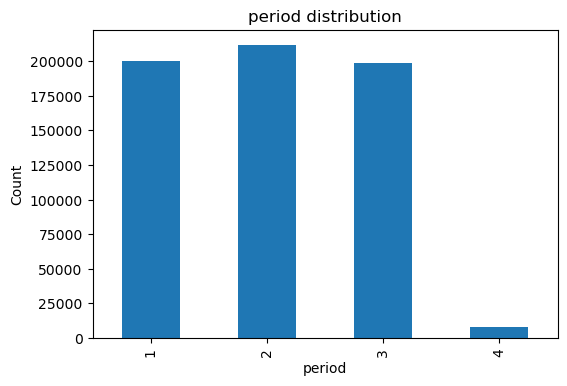

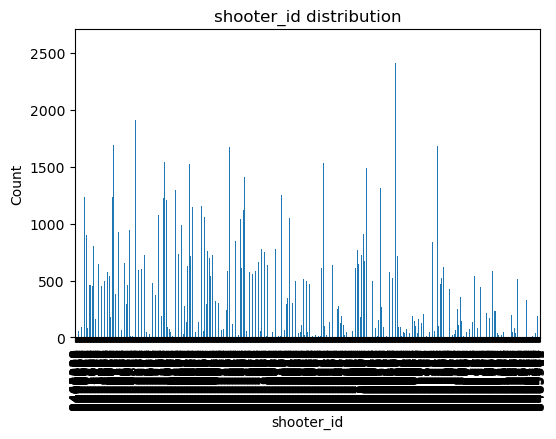

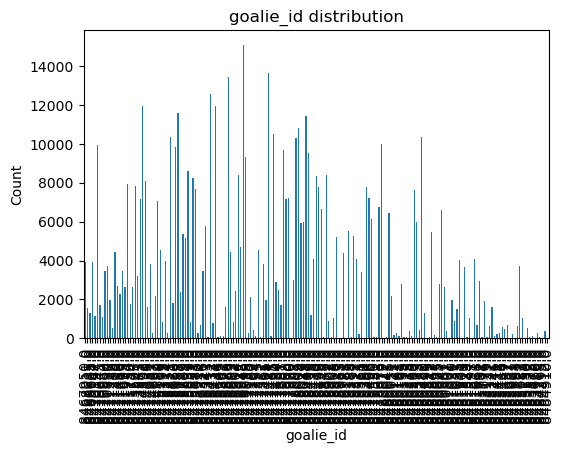

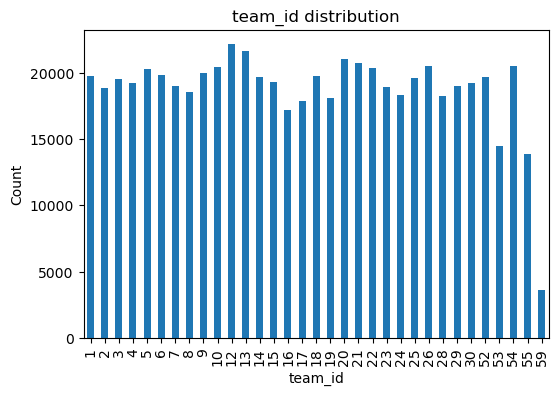

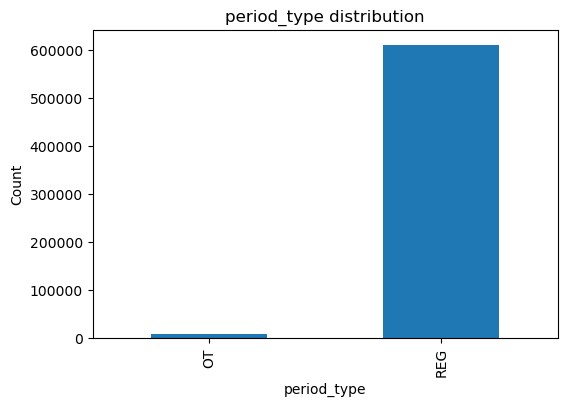

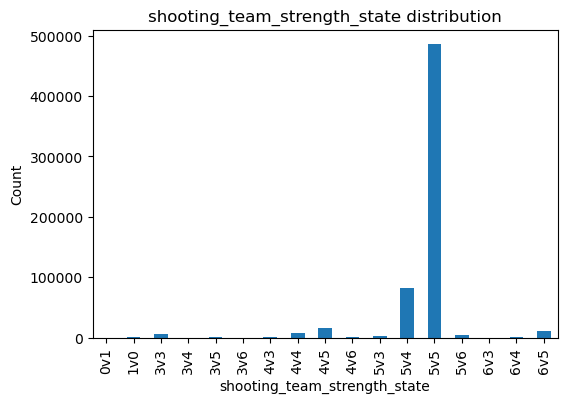

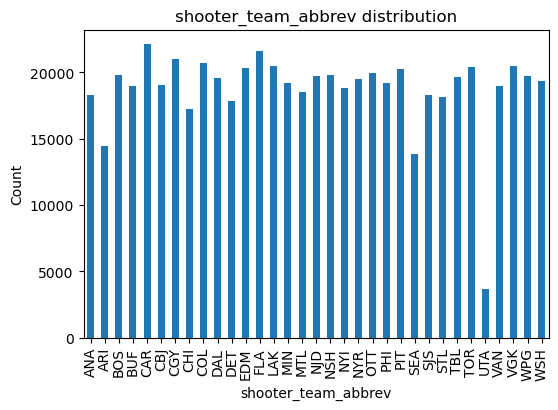

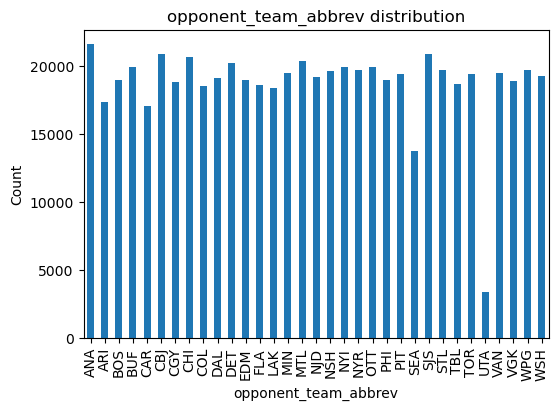

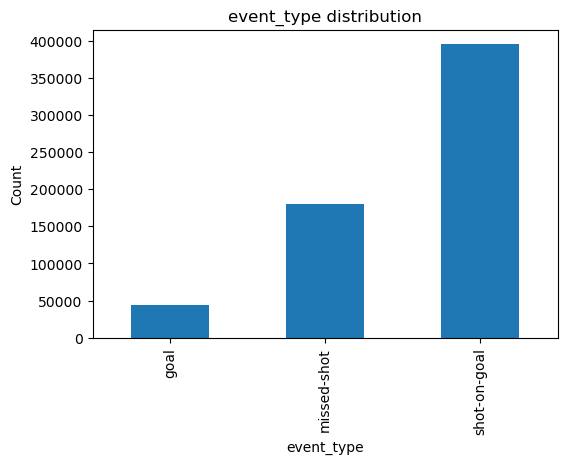

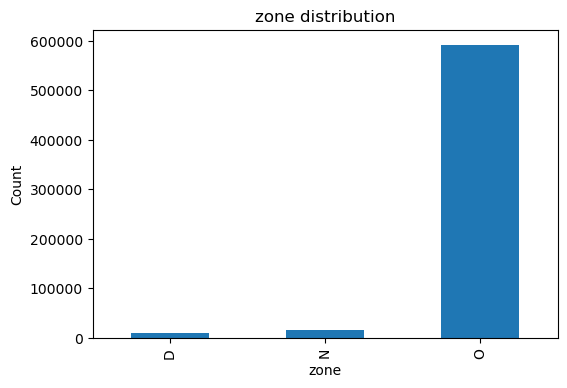

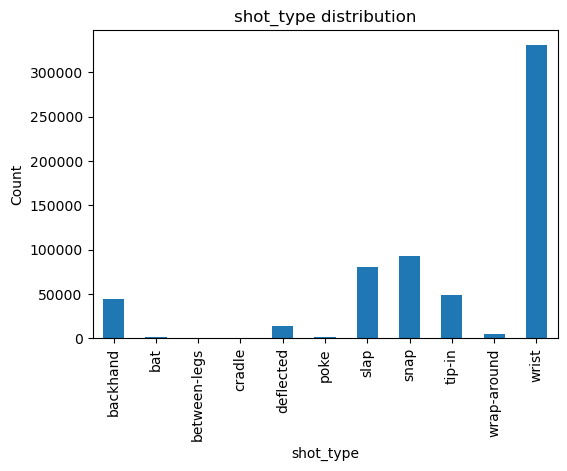

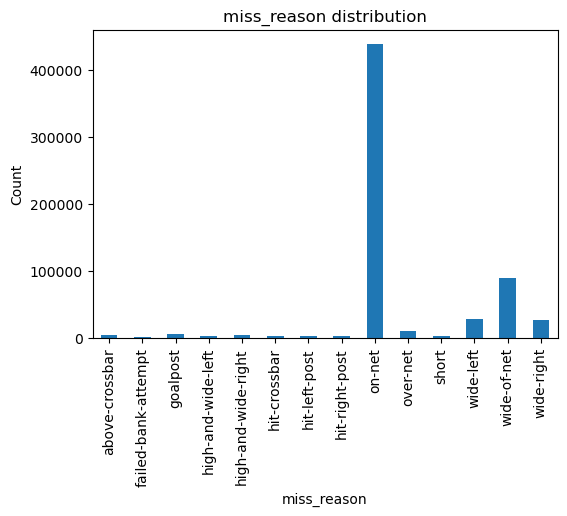

In [34]:
num_cat = ['period', 'shooter_id', 'goalie_id', 'team_id', 'period_type', 'shooting_team_strength_state', 'shooter_team_abbrev', 'opponent_team_abbrev', 'event_type', 'zone', 'shot_type', 'miss_reason']
for col in num_cat:
    plt.figure(figsize=(6,4))
    counts = df[col].value_counts().sort_index()
    counts.plot(kind='bar')
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
